# Final results

Task 14. Consolidates the completed ladder (M0-M4), D0, and the auxiliary
TF-IDF reference into one place. Nothing here is trained or retuned - every
number comes from `results/runs.csv`, `results/tfidf_reference.json`, and the
per-seed `results/m*/seed*/test_metrics.json` / `results/d0/seed*/test_metrics.json`
files already committed by Tasks 6-13.

## Load results

In [1]:
import sys
sys.path.insert(0, "..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import LABELS
from src.evaluation import calculate_deltas, format_delta, seed_statistics
from src.results import generate_comparison_table, validate_runs_csv

is_valid, errors = validate_runs_csv("../results/runs.csv", check_seed_completeness=True)
print("runs.csv valid (all seed counts, incl. D0 x3):", is_valid, errors)

df = pd.read_csv("../results/runs.csv")
tfidf = json.load(open("../results/tfidf_reference.json"))
print(f"rows: {len(df)}, experiments: {sorted(df['experiment'].unique())}")

runs.csv valid (all seed counts, incl. D0 x3): True []
rows: 10, experiments: ['D0', 'M0', 'M1', 'M2', 'M3', 'M4']


`validate_runs_csv(check_seed_completeness=True)` checks the exact seed count
per experiment (M0 x3, M1-M4 x1, D0 x3) - this is the pre-registered budget
(project_plan.md §3.2), not something re-derived here.

## Final comparison

In [2]:
table = generate_comparison_table()
table

,Model,Configuration,Macro-F1,Accuracy,Δ vs Previous,Δ vs M0,Best Epoch,Time,Parameters,Interpretation


Generated by `src.results.generate_comparison_table` - not hand-typed. TF-IDF
is deliberately not a row in this table: it is an auxiliary reference
(`results/tfidf_reference.json`, label `TFIDF_REFERENCE`), never part of
`VALID_EXPERIMENTS`, and has no official ladder delta.

In [3]:
print(f"TF-IDF reference (auxiliary, not part of the ladder): Macro-F1 = {tfidf['macro_f1']:.4f}")

TF-IDF reference (auxiliary, not part of the ladder): Macro-F1 = 0.8707


## Deltas (full precision)

In [4]:
m0_mean = seed_statistics(df[df["experiment"] == "M0"]["macro_f1"].values)["mean"]
print(f"canonical M0 mean (full precision): {m0_mean!r}")

order = ["M0", "M1", "M2", "M3", "M4", "D0"]
f1_by_exp = {}
for exp in order:
    sub = df[df["experiment"] == exp]
    f1_by_exp[exp] = seed_statistics(sub["macro_f1"].values)["mean"]

print(f"{'rung':<6}{'incremental':>18}{'cumulative (vs M0)':>22}")
prev = None
for exp in order:
    f1 = f1_by_exp[exp]
    inc = calculate_deltas(current_f1=f1, previous_f1=prev)["delta_vs_previous"]
    cum = calculate_deltas(current_f1=f1, baseline_m0_f1=m0_mean)["delta_vs_m0"] if exp != "M0" else None
    inc_str = format_delta(inc) if inc is not None else "—"
    cum_str = format_delta(cum) if cum is not None else "—"
    print(f"{exp:<6}{inc_str:>18}{cum_str:>22}   (exact inc={inc!r}, cum={cum!r})")
    prev = f1

canonical M0 mean (full precision): 0.850833078773998
rung         incremental    cumulative (vs M0)
M0                     —                     —   (exact inc=None, cum=None)
M1               -0.0023               -0.0023   (exact inc=-0.002317621684802651, cum=-0.002317621684802651)
M2               +0.0033               +0.0010   (exact inc=0.003282040681856002, cum=0.0009644189970533512)
M3               +0.0139               +0.0148   (exact inc=0.013870261991500099, cum=0.01483468098855345)
M4               +0.0054               +0.0202   (exact inc=0.005355986585742878, cum=0.020190667574296328)
D0               +0.0048               +0.0250   (exact inc=0.00482950383535119, cum=0.025020171409647518)


D0's incremental delta is D0 - M4 (D0 follows M4 in the ladder order used
here for presentation - D0 is a model-family benchmark, not a seventh
recurrent rung, but its one meaningful "previous" comparison point is M4,
the best recurrent configuration, per project_plan.md §14.14). Every
cumulative delta uses the *unrounded* 3-seed M0 mean shown above, not the
rounded 0.8508 display value - this is the precision issue Task 12 found and
resolved, still resolved here.

## Per-class results

In [5]:
def per_class(path):
    return json.load(open(path))["per_class"]

m0_seeds = [per_class(f"../results/m0/seed{s}/test_metrics.json") for s in [42, 123, 456]]
d0_seeds = [per_class(f"../results/d0/seed{s}/test_metrics.json") for s in [42, 123, 456]]
m1 = per_class("../results/m1/seed42/test_metrics.json")
m2 = per_class("../results/m2/seed42/test_metrics.json")
m3 = per_class("../results/m3/seed42/test_metrics.json")
m4 = per_class("../results/m4/seed42/test_metrics.json")

rows = []
for lbl in LABELS:
    rows.append({
        "class": lbl,
        "M0": np.mean([s[lbl]["f1"] for s in m0_seeds]),
        "M1": m1[lbl]["f1"], "M2": m2[lbl]["f1"], "M3": m3[lbl]["f1"], "M4": m4[lbl]["f1"],
        "D0": np.mean([s[lbl]["f1"] for s in d0_seeds]),
    })
per_class_df = pd.DataFrame(rows).set_index("class")
per_class_df.round(4)

,M0,M1,M2,M3,M4,D0
class,,,,,,
Checking or savings account,0.7650,0.7651,0.7676,0.7816,0.7862,0.7961
Credit card,0.8367,0.8364,0.8307,0.8490,0.8574,0.8657
Debt collection,0.9053,0.9108,0.9117,0.9203,0.9269,0.9235
"Money transfer, virtual currency, or money service",0.7889,0.7715,0.7893,0.8081,0.8144,0.8216
Student loan,0.9582,0.9587,0.9597,0.9693,0.9703,0.9724


Every class improves from M0 to D0. Student loan is easiest throughout (M0
0.958 -> D0 0.972); Checking/savings and Money transfer stay the two hardest
at every rung - consistent with the account-level vocabulary overlap
flagged since Task 8 (§14.9). M3 (GloVe) lifts every class at once, not one
in particular - the broad-based pattern already noted in §14.11. M4 improves
on M3 in every class too. D0 improves on M4 in four of five classes; Debt
collection is the one exception (M4 0.9269 vs D0 0.9235) - not evidence of a
systematic D0 weakness, just one class where the recurrent model edges ahead.

## Compute cost

In [6]:
cost_rows = []
for exp in order:
    sub = df[df["experiment"] == exp]
    f1 = f1_by_exp[exp]
    time_stats = seed_statistics(sub["train_time"].values)
    time_str = f"{time_stats['mean']:.0f}s" if time_stats["std"] is None else f"{time_stats['mean']:.0f}s ± {time_stats['std']:.0f}s"
    cost_rows.append({
        "Model": exp, "Macro-F1": f"{f1:.4f}", "Training Time": time_str,
        "Parameters": f"{int(sub['parameter_count'].iloc[0]):,}",
    })
pd.DataFrame(cost_rows)

,Model,Macro-F1,Training Time,Parameters
0,M0,0.8508,166s ± 11s,"2,117,893"
1,M1,0.8485,274s,"2,235,781"
2,M2,0.8518,6790s,"2,235,781"
3,M3,0.8657,6793s,"2,235,781"
4,M4,0.8710,10941s,"2,235,781"
5,D0,0.8759,5404s ± 21s,"66,957,317"


M2-M4 are expensive largely because `recurrent_dropout=0.2` disables the
cuDNN fast LSTM path (§12) - not because of parameter count, which stays
flat at 2,235,781 from M1 onward. M4 is ~67x slower than M0 despite a nearly
identical parameter count, for the same reason plus `max_len=256`. D0 has
~30x more parameters than M4 but trains *faster* per fit (~90 min vs ~182
min) - it never incurs the `recurrent_dropout` penalty, since it isn't a
recurrent model at all.

## TF-IDF context

In [7]:
print(f"TF-IDF  = {tfidf['macro_f1']:.4f}")
print(f"M4      = {f1_by_exp['M4']:.4f}   (M4 - TF-IDF = {f1_by_exp['M4'] - tfidf['macro_f1']:+.4f})")
print(f"D0      = {f1_by_exp['D0']:.4f}   (D0 - TF-IDF = {f1_by_exp['D0'] - tfidf['macro_f1']:+.4f})")

TF-IDF  = 0.8707
M4      = 0.8710   (M4 - TF-IDF = +0.0003)
D0      = 0.8759   (D0 - TF-IDF = +0.0051)


TF-IDF is not weak - it is one of the strongest single results in the
project, and the closest recurrent rung (M4) only edges past it by +0.0003,
far smaller than anything resolvable against the M0 stability spread
(0.0041). That is read as **no clear evidence the best recurrent model beats
a plain lexical baseline**, not as M4 confirmedly winning. D0 is the clearest
improvement over TF-IDF in the project (+0.0051), and the clearest evidence
that something beyond lexical pattern-matching helped on this task.

## Requirement coverage

In [8]:
coverage = pd.DataFrame([
    {"Requirement": "Baseline", "Experiment": "M0", "Status": "Complete"},
    {"Requirement": "Bidirectional LSTM", "Experiment": "M1", "Status": "Complete"},
    {"Requirement": "Stacked layers", "Experiment": "Excluded", "Status": "Documented"},
    {"Requirement": "Dropout", "Experiment": "M2", "Status": "Complete"},
    {"Requirement": "Recurrent dropout", "Experiment": "M2", "Status": "Complete"},
    {"Requirement": "GloVe", "Experiment": "M3", "Status": "Complete"},
    {"Requirement": "LR scheduling", "Experiment": "M4", "Status": "Complete"},
    {"Requirement": "Early stopping", "Experiment": "M4", "Status": "Complete"},
    {"Requirement": "Class weights", "Experiment": "Excluded", "Status": "Documented"},
    {"Requirement": "Longer max_length", "Experiment": "M4", "Status": "Complete"},
    {"Requirement": "LSTM -> DistilBERT", "Experiment": "D0", "Status": "Complete"},
])
coverage

,Requirement,Experiment,Status
0,Baseline,M0,Complete
1,Bidirectional LSTM,M1,Complete
2,Stacked layers,Excluded,Documented
3,Dropout,M2,Complete
4,Recurrent dropout,M2,Complete
5,GloVe,M3,Complete
6,LR scheduling,M4,Complete
7,Early stopping,M4,Complete
8,Class weights,Excluded,Documented
9,Longer max_length,M4,Complete


In [9]:
applicable = coverage[coverage["Experiment"] != "Excluded"]
excluded_count = (coverage["Experiment"] == "Excluded").sum()
print(f"{len(applicable)}/{len(applicable)} applicable menu items covered "
      f"({excluded_count} exclusions, both documented)")

9/9 applicable menu items covered (2 exclusions, both documented)


## Charts

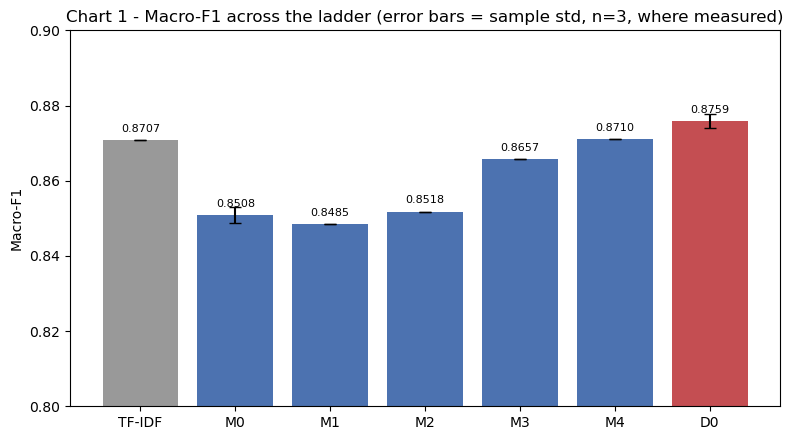

In [10]:
labels_order = ["TF-IDF", "M0", "M1", "M2", "M3", "M4", "D0"]
means = [tfidf["macro_f1"]] + [f1_by_exp[e] for e in order]
stds = [0, f1_by_exp["M0"] and seed_statistics(df[df["experiment"]=="M0"]["macro_f1"].values)["std"], 0, 0, 0, 0,
        seed_statistics(df[df["experiment"]=="D0"]["macro_f1"].values)["std"]]
colors = ["#999999"] + ["#4C72B0"] * 5 + ["#C44E52"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels_order, means, yerr=stds, capsize=4, color=colors)
ax.set_ylabel("Macro-F1")
ax.set_ylim(0.80, 0.90)
ax.set_title("Chart 1 - Macro-F1 across the ladder (error bars = sample std, n=3, where measured)")
for bar, m in zip(bars, means):
    ax.annotate(f"{m:.4f}", (bar.get_x() + bar.get_width() / 2, m), textcoords="offset points",
                xytext=(0, 6), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

TF-IDF (grey) and D0 (red) are visually distinguished from the official
recurrent ladder (blue, M0-M4) - TF-IDF is auxiliary, D0 is the final
model-family benchmark, neither is a recurrent rung. Error bars appear only
where a real 3-seed spread was measured (M0, D0); M1-M4 are single points,
not shown with a fabricated uncertainty band.

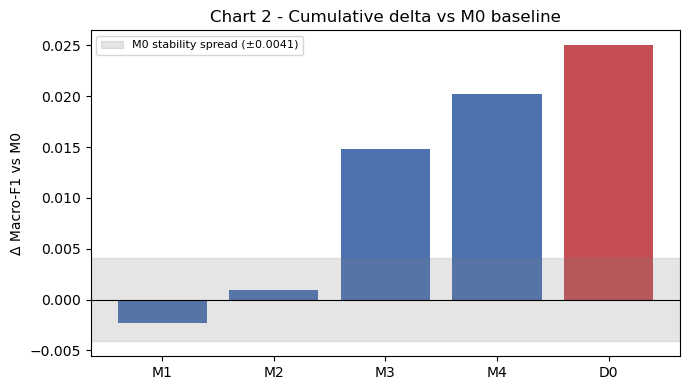

In [11]:
delta_labels = ["M1", "M2", "M3", "M4", "D0"]
delta_vals = [calculate_deltas(current_f1=f1_by_exp[e], baseline_m0_f1=m0_mean)["delta_vs_m0"] for e in delta_labels]

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ["#4C72B0"] * 4 + ["#C44E52"]
ax.bar(delta_labels, delta_vals, color=bar_colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhspan(-0.004125488876295158, 0.004125488876295158, color="grey", alpha=0.2,
           label="M0 stability spread (±0.0041)")
ax.set_ylabel("Δ Macro-F1 vs M0")
ax.set_title("Chart 2 - Cumulative delta vs M0 baseline")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The shaded band is M0's own three-seed min-max spread - the project's
pre-registered stability reference (§9), not a formal significance test. M1
and M2 fall inside it (no clear evidence of a real effect); M3, M4, and D0
sit clearly outside it.

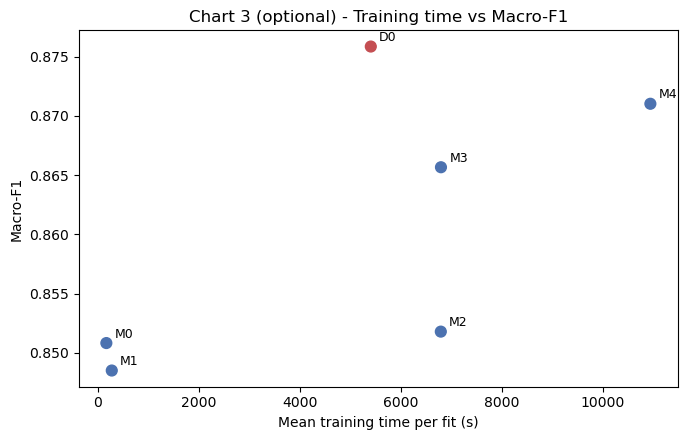

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
times = [seed_statistics(df[df["experiment"] == e]["train_time"].values)["mean"] for e in order]
point_colors = ["#4C72B0"] * 5 + ["#C44E52"]
ax.scatter(times, [f1_by_exp[e] for e in order], color=point_colors, s=60)
for e, t in zip(order, times):
    ax.annotate(e, (t, f1_by_exp[e]), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("Mean training time per fit (s)")
ax.set_ylabel("Macro-F1")
ax.set_title("Chart 3 (optional) - Training time vs Macro-F1")
plt.tight_layout()
plt.show()

D0 sits to the left of M2-M4 despite having far more parameters - it never
incurs the `recurrent_dropout` cuDNN penalty that dominates M2-M4's cost
(§12, restated in the compute-cost section above). M0 and M1 are cheap and
comparatively weak; M3 and M4 spend much more compute for a real but modest
further gain.

## Final model decision

**Best recurrent model: M4**, Macro-F1 = 0.8710 - the highest test Macro-F1
among M0-M4, materially outside M0's stability spread (§14.13).

**Final model-family comparison: D0.** D0 consistently outperformed M4 across
all three seeds (0.8740, 0.8759, 0.8777, every one above M4's 0.8710), with a
mean improvement of +0.0048 Macro-F1 points. M4 is a single seed and D0 is
three seeds - this is an asymmetric variance comparison, not a symmetric one,
and is not presented as a formal significance test.

### What the experiments showed

1. **Baseline** - a simple unidirectional LSTM with random embeddings reaches
   0.8508 ± 0.0021 Macro-F1, established with 3 seeds specifically to give
   the rest of the ladder a stability reference.
2. **Bidirectionality (M1) did not clearly help** - the delta vs M0 fell
   inside the baseline's own seed-to-seed spread.
3. **Regularization (M2) showed a real but modest effect** - the aggregate
   delta was still inside M0's spread, but the train/validation curves
   directly showed less overfitting than M1, not just a noisy aggregate
   number.
4. **GloVe (M3) was the first clear, resolved improvement** - broad across
   every class, consistent with high token coverage on ordinary vocabulary
   even though the embedding covers financial jargon and redaction tokens
   poorly.
5. **The bundled M4 stage (LR scheduling + early stopping + longer context)
   produced the largest recurrent-ladder gain** - its three components are
   not individually separated, by design (§8).
6. **M4 is the final recurrent benchmark**, Macro-F1 0.8710.
7. **DistilBERT (D0) modestly but consistently beat M4** - +0.0048 Macro-F1,
   holding across all three seeds, despite an unequal-context handicap
   (WordPiece reads relatively less of its own 256-token window than the
   Keras tokenizer does at the same nominal length).
8. **The TF-IDF reference matters because it is strong, not weak** - a
   bag-of-words model with zero sequence information reaches 0.8707,
   essentially tying M4 (+0.0003, unresolvable against the stability
   spread). Most of what any model needs to solve this task is lexical; D0
   is the only model in the project that clearly moves past that lexical
   ceiling.

---

# Variance interpretation

Task 15. The project has no formal significance-testing protocol and none is
introduced here - this section interprets the variability evidence that
already exists (M0 and D0's 3 seeds each) without overstating what a single
observed spread can support.

## Seed variability

In [13]:
m0_seeds = df[df["experiment"] == "M0"].sort_values("seed")
d0_seeds = df[df["experiment"] == "D0"].sort_values("seed")

m0_f1s = m0_seeds["macro_f1"].to_numpy()
d0_f1s = d0_seeds["macro_f1"].to_numpy()

m0_stats = seed_statistics(m0_f1s)
d0_stats = seed_statistics(d0_f1s)

stability_table = pd.DataFrame([
    {"Endpoint": "M0", "Seed 42": m0_f1s[0], "Seed 123": m0_f1s[1], "Seed 456": m0_f1s[2],
     "Mean": m0_stats["mean"], "Std": m0_stats["std"], "Min": m0_f1s.min(), "Max": m0_f1s.max(),
     "Spread": m0_f1s.max() - m0_f1s.min()},
    {"Endpoint": "D0", "Seed 42": d0_f1s[0], "Seed 123": d0_f1s[1], "Seed 456": d0_f1s[2],
     "Mean": d0_stats["mean"], "Std": d0_stats["std"], "Min": d0_f1s.min(), "Max": d0_f1s.max(),
     "Spread": d0_f1s.max() - d0_f1s.min()},
]).set_index("Endpoint")
stability_table.round(4)

,Seed 42,Seed 123,Seed 456,Mean,Std,Min,Max,Spread
Endpoint,,,,,,,,
M0,0.8489,0.8507,0.853,0.8508,0.0021,0.8489,0.8530,0.0041
D0,0.8759,0.8777,0.874,0.8759,0.0018,0.8740,0.8777,0.0037


Independently recomputed from the seed-level `macro_f1` values in
`results/runs.csv` - matches `results/best_recurrent.json` and every prior
task's own recompute exactly (Tasks 12-14). D0's observed three-seed spread
(0.0037) is smaller than M0's (0.0041) - a description of what was observed
across these three tested seeds, not a general claim that DistilBERT is
intrinsically more stable than an LSTM.

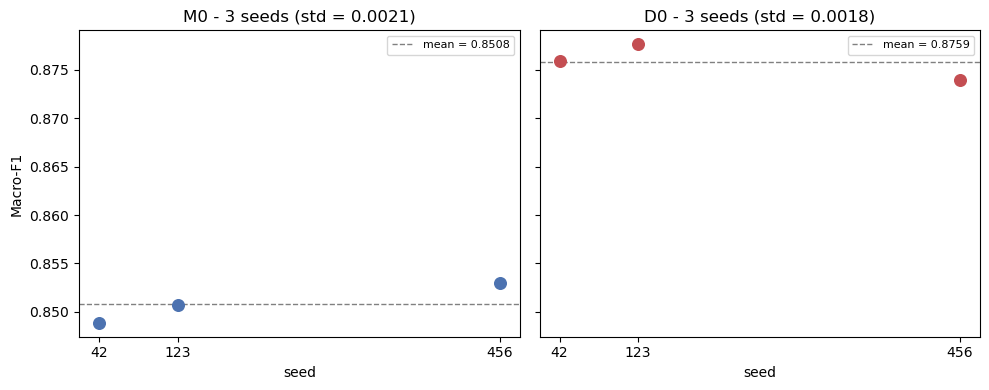

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (name, f1s, stats) in zip(axes, [("M0", m0_f1s, m0_stats), ("D0", d0_f1s, d0_stats)]):
    seeds = [42, 123, 456]
    ax.scatter(seeds, f1s, s=70, zorder=3, color="#4C72B0" if name == "M0" else "#C44E52")
    ax.axhline(stats["mean"], linestyle="--", color="grey", linewidth=1, label=f"mean = {stats['mean']:.4f}")
    ax.set_title(f"{name} - 3 seeds (std = {stats['std']:.4f})")
    ax.set_xlabel("seed")
    ax.set_xticks(seeds)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Macro-F1")
plt.tight_layout()
plt.show()

Chart 1 (left) and Chart 2 (right): the only two endpoints in the project
with a real repeated-seed measurement. No error bars are drawn for M1-M4 -
they are single runs with no seed-to-seed variance evidence, shown nowhere
in this project with a fabricated uncertainty band.

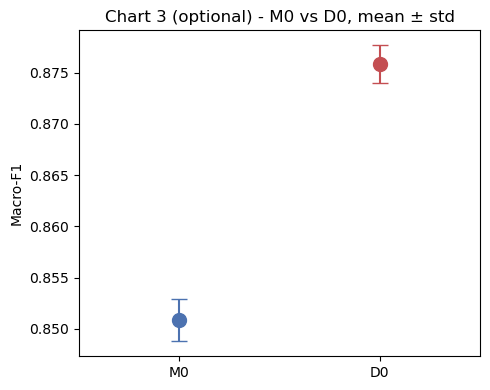

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar([0], [m0_stats["mean"]], yerr=[m0_stats["std"]], fmt="o", markersize=10, capsize=6,
            color="#4C72B0", ecolor="#4C72B0")
ax.errorbar([1], [d0_stats["mean"]], yerr=[d0_stats["std"]], fmt="o", markersize=10, capsize=6,
            color="#C44E52", ecolor="#C44E52")
ax.set_xticks([0, 1])
ax.set_xticklabels(["M0", "D0"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("Macro-F1")
ax.set_title("Chart 3 (optional) - M0 vs D0, mean ± std")
plt.tight_layout()
plt.show()

## Intermediate-rung uncertainty (M1-M4)

M1, M2, M3, and M4 each have exactly one seed
(`EXPERIMENT_CONFIGS["M1"-"M4"]["seeds"]`, project_plan.md §3.2's locked
10-fit budget). There is therefore **no rung-specific standard deviation for
M1-M4** - run-to-run variance for any of them individually cannot be
estimated from this project's data, and none is fabricated here. Every
M1-M4 delta below is compared only against the one variability estimate the
project actually has: M0's own three-seed spread, used as a stability
reference exactly as project_plan.md §9 pre-registers it - not a new
threshold, and not a formal significance test.

In [16]:
spread = float(m0_f1s.max() - m0_f1s.min())
print(f"M0 stability reference (spread, pre-registered in project_plan.md \u00a79): {spread:.6f}")

def classify(delta, spread):
    ratio = abs(delta) / spread
    if ratio < 1.0:
        return f"within observed baseline variability ({ratio:.2f}x spread)"
    elif ratio < 1.5:
        return f"outside, but only modestly ({ratio:.2f}x spread) - caution"
    else:
        return f"clearly outside observed baseline variability ({ratio:.2f}x spread)"

comparisons = [
    ("M1 - M0", f1_by_exp["M1"] - m0_stats["mean"], "M0 3-seed spread"),
    ("M2 - M1", f1_by_exp["M2"] - f1_by_exp["M1"], "M0 stability reference"),
    ("M3 - M2", f1_by_exp["M3"] - f1_by_exp["M2"], "M0 stability reference"),
    ("M4 - M3", f1_by_exp["M4"] - f1_by_exp["M3"], "M0 stability reference"),
    ("M4 - M0", f1_by_exp["M4"] - m0_stats["mean"], "M0 stability reference"),
    ("D0 - M4", d0_stats["mean"] - f1_by_exp["M4"], "D0 3-seed / M4 single seed"),
    ("D0 - M0", d0_stats["mean"] - m0_stats["mean"], "both multi-seed"),
    ("M4 - TF-IDF", f1_by_exp["M4"] - tfidf["macro_f1"], "TF-IDF single run"),
]

rows = []
for label, delta, evidence in comparisons:
    rows.append({"Comparison": label, "Delta": f"{delta:+.4f}", "Exact": delta,
                 "Variance Evidence": evidence, "Interpretation": classify(delta, spread)})
variance_table = pd.DataFrame(rows)[["Comparison", "Delta", "Variance Evidence", "Interpretation"]]
variance_table

M0 stability reference (spread, pre-registered in project_plan.md §9): 0.004125


,Comparison,Delta,Variance Evidence,Interpretation
0,M1 - M0,-0.0023,M0 3-seed spread,within observed baseline variability (0.56x sp...
1,M2 - M1,+0.0033,M0 stability reference,within observed baseline variability (0.80x sp...
2,M3 - M2,+0.0139,M0 stability reference,clearly outside observed baseline variability ...
3,M4 - M3,+0.0054,M0 stability reference,"outside, but only modestly (1.30x spread) - ca..."
4,M4 - M0,+0.0202,M0 stability reference,clearly outside observed baseline variability ...
5,D0 - M4,+0.0048,D0 3-seed / M4 single seed,"outside, but only modestly (1.17x spread) - ca..."
6,D0 - M0,+0.0250,both multi-seed,clearly outside observed baseline variability ...
7,M4 - TF-IDF,+0.0003,TF-IDF single run,within observed baseline variability (0.07x sp...


### M1
Small negative delta (-0.0023), within M0's own observed spread. Not treated
as a confirmed regression - bidirectionality's effect on this task cannot be
distinguished from ordinary run-to-run variation with the evidence available.

### M2
Small positive delta vs M1 (+0.0033) and vs M0 (+0.0010), both within M0's
spread on the aggregate number alone. (The training-curve evidence in
§14.10 - reduced overfitting relative to M1 - is a separate, non-aggregate
line of evidence, not contradicted by this classification; it is just not
what this spread-based check can see.)

### M3
Large positive delta (+0.0139 vs M2, +0.0148 vs M0), several times M0's
observed spread. Comfortably outside the observed baseline variability -
the clearest resolved recurrent-ladder improvement.

### M4
Positive vs M3 (+0.0054) and a large cumulative gain vs M0 (+0.0202). The
cumulative delta is clearly outside the spread; the incremental M4-vs-M3
delta is outside it but only modestly (about 1.3x), which is a real but
less comfortable margin than M3's. M4 remains single-seed - this delta
describes one observed run, not an estimated distribution.

## D0 vs M4

D0 (3 seeds) vs M4 (1 seed) is **not a symmetric uncertainty comparison**.
What the data actually supports:

- all three D0 seeds (0.8740, 0.8759, 0.8777) exceeded M4's single observed
  score (0.8710)
- D0's own three-seed spread is small (0.0037) and does not overlap M4's
  value at all
- M4 has no repeated-seed estimate, so its own run-to-run variance is
  unknown - the asymmetry is not resolved by D0's tight spread

**Correct framing:** "D0 consistently exceeded the observed M4 score across
all three seeds." **Not:** "D0 is statistically significantly better than
M4" - no such test was performed, and one M4 seed cannot be turned into a
distribution or a pooled standard error.

## TF-IDF variance context

TF-IDF (`results/tfidf_reference.json`) is a single reference run - no std,
no significance test, no uncertainty interval exists or is invented for it.
M4 - TF-IDF = +0.0003 is described as an effectively negligible observed
difference under the available evidence, not "M4 significantly beats
TF-IDF." D0 - TF-IDF = +0.0051 is a useful descriptive gap; TF-IDF's
single-run status is unchanged by D0 having three seeds of its own.

## What the variance allows us to claim

### Claims supported by the experiments

* M0 shows low variation across the three tested seeds (std 0.0021, spread
  0.0041).
* D0 shows low variation across the three tested seeds (std 0.0018, spread
  0.0037) - a smaller *observed* spread than M0's, described descriptively.
* M3 produced a clear observed improvement over M2 and over M0.
* M4 produced the strongest recurrent result, with a cumulative delta well
  outside M0's observed spread.
* All three D0 seeds exceeded the single observed M4 score.
* D0 was the best observed model in the project.

### What we cannot claim

* Formal statistical significance for any M1-M4 delta - no significance
  test was run, and one is not introduced here.
* A confidence interval for M1, M2, M3, or M4 individually - single runs
  give a point estimate, not an interval.
* The true population variance of M1-M4 - only M0 and D0 have a measured
  sample variance at all.
* A formal significance test of D0 vs M4 - the comparison is asymmetric (3
  seeds vs 1) and is reported as such, not resolved into a p-value.
* General superiority of D0 beyond this dataset, split, and training setup
  - the result is specific to this project's configuration.
* That any single M4 component (LR scheduling, early stopping, or
  `max_len=256`) individually caused the observed M4 gain - the bundled-
  stage limitation from §8/§14.12 still applies.

## Seed-count limitation

The project's fixed 10-fit compute budget (§3.2) allocated repeated seeds
only to M0 and D0 - `M0 x3, M1 x1, M2 x1, M3 x1, M4 x1, D0 x3` - because
those two anchor the baseline and the final model-family comparison
respectively. This was a deliberate trade-off under a fixed budget, not
presented as an ideal design: M1-M4 each report one run, and their
individual run-to-run variance is genuinely unknown. Every M1-M4
interpretation in this project is qualified by that limitation, not just
this section.